In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
def log_label(x,pos):
        if np.isclose(x,0):
            return "0"
        sign= "-" if x<0 else ""
        exp=int(np.round(abs(x)))
        return rf"${sign}10^{{{abs(int(x))}}}$"



def plot_flame_contour(df_ff01,df_ff05,label1='c=0.1',label2='c=0.5'):
    fig,ax = plt.subplots(figsize=(12,9))
    ax.plot(df_ff01['x_grid'],df_ff01['y_grid'],'.',markersize=2,color='dimgrey',label=label1)
    ax.plot(df_ff05['x_grid'],df_ff05['y_grid'],'.',markersize=2,color='black',label=label2)
    
    return fig,ax

def plot_sr_sum_v11(df_ff01,df_ff05,df,sr_threshold,i,name,file_label=''):
    df2 = df.copy()


    #df2 = df[df['Sd'].notna()].copy()
    try:
        df2['stretch_rate'] = df2['div_u'] + df2['k']*df2['Sd']
    except:
        print("Unable to get Stretch rate!!!")

    df2_flame = df2[ (df2['c']>=0.15) & (df2['c']<=0.85) & (df2['Sd'] == df2['Sd'] ) ]
    max_str = df2_flame['stretch_rate'].max()
    # plot flame range
    fig,ax=plot_flame_contour(df_ff01,df_ff05,label1='c=0.15',label2='c=0.85')
    pn_divu = np.where(df2['div_u']>0,1,-1)
    log_abs_divu = np.log10(abs(df2['div_u'])+1e-5)
    df2['pn_log_divu'] = pn_divu  * log_abs_divu
    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )
    pn_str = np.where(df2['stretch_rate']>0,1,-1)
    log_abs_str = np.log10(abs(df2['stretch_rate'])+1e-5)
    df2_flame['np_log_str'] = pn_str*log_abs_str
    str_grid = df2_flame.pivot_table(index='y_grid', columns='x_grid', values='np_log_str', aggfunc='median',)
    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values
    
    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values
    
    max_sr = np.abs(df2[df2['c']<=0.5]['div_u']).max()
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    cf=ax.contourf(X,Y,Z,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax, alpha=0.7 )
    cf1 = ax.contourf(X1,Y1,Z1,levels=levels,cmap='bwr',vmin=vmin,vmax=vmax,)
    cf2= ax.contourf(X1,Y1,np.abs(Z1)>=np.log10(sr_threshold),levels=[0.5,1],hatches=['xx'],alpha=0.5,)
    cbar =plt.colorbar(cf,ax=ax,label='Strain Rate in power of 10-scale')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_aspect('equal')
    ax.set_xlim(3510,4050)
    ax.set_ylim(0,1024)
    ax.set_xlabel('x_grid')
    ax.set_ylabel('y_grid')
    ax.set_title(f'z_grid={i} w/ max stretch rate:{round(max_str,2)} 1/s,\n max abs strain rate :{round(max_sr,2)} 1/s.')
    ax.legend()
    fig.tight_layout()
    plt.savefig(f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_(sr)(str)sum_z={i}.png',dpi=600)
    print(f'plot saved for layer i={i}!')
    plt.show()

def plot_sr_sum(
    df_fflow,
    df_ffhigh,
    df,
    sr_threshold,
    i,
    name,
    file_label='',
):

    df2=df.copy()    
    
    df2_flame=df2[
        (df2['c']>=0.2)
        &
        (df2['c']<=0.8)
        &
        (df2['Sd'].notna())
    ].copy()
    try:
        df2_flame = df2.copy()
        df2_flame['stretch_rate']=(
            df2_flame['div_u']
            +
            df2_flame['k']*df2_flame['Sd']
        )
        max_str=df2_flame['stretch_rate'].max()
    except:
        print("Unable to get Stretch rate at begining!!!")
    
    
    df2_flame['sdk']=(
        df2_flame['Sd']
        *
        df2_flame['k']
    )
    #print(df2.columns)
    #print(df2_flame.columns)

    

    fig,axs=plt.subplots(
        2,
        2,
        figsize=(18,18)
    )

    ax=axs[0,0]
    ax_sd=axs[1,1]
    ax_k=axs[1,0]
    ax_sdk=axs[0,1]

    # ============================================================
    # flame contours on all panels
    # ============================================================
    #df_ff015 = df2[df2['c']>=0.15]
    #df_ff085 = df2[df2['c']>=0.85]
    #df_fflow = df2_flame.loc[df2_flame.groupby('y_grid')['x_grid'].idxmin()].copy()
    #df_ffhigh = df2_flame.loc[df2_flame.groupby('y_grid')['x_grid'].idxmax()].copy()
    for a in [ax,ax_sd,ax_k,ax_sdk]:

        a.plot(
            df_fflow['x_grid'],
            df_fflow['y_grid'],
            '.',
            markersize=2,
            color='dimgrey',
            label='c=0.2'
        )

        a.plot(
            df_ffhigh['x_grid'],
            df_ffhigh['y_grid'],
            '.',
            markersize=2,
            color='black',
            label='c=0.8'
        )
        a.legend(loc=2)

    # ============================================================
    # original strain/stretch panel
    # ============================================================

    pn_divu=np.where(
        df2['div_u']>0,
        1,
        -1
    )

    log_abs_divu=np.log10(
        np.abs(df2['div_u'])+1e-5
    )

    df2['pn_log_divu']=(
        pn_divu
        *
        log_abs_divu
    )

    divu_grid=df2.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_divu',
        aggfunc='median',
    )

    pn_str=np.where(
        df2_flame['stretch_rate']>0,
        1,
        -1
    )

    log_abs_str=np.log10(
        np.abs(df2_flame['stretch_rate'])+1e-5
    )

    df2_flame['pn_log_str']=(
        pn_str
        *
        log_abs_str
    )

    str_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='pn_log_str',
        aggfunc='median',
    )

    X=divu_grid.columns.values
    Y=divu_grid.index.values
    Z=divu_grid.values

    X1=str_grid.columns.values
    Y1=str_grid.index.values
    Z1=str_grid.values

    levels=np.linspace(
        -4,
        4,
        33
    )

    cf=ax.contourf(
        X,
        Y,
        Z,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
        alpha=0.7
    )

    cf1=ax.contourf(
        X1,
        Y1,
        Z1,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cf2=ax.contourf(
        X1,
        Y1,
        np.abs(Z1)>=np.log10(sr_threshold),
        levels=[0.5,1],
        hatches=['xx'],
        alpha=0.5,
    )

    cbar=plt.colorbar(
        cf,
        ax=ax
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    max_sr=np.abs(
        df2[df2['c']<=0.5]['div_u']
    ).max()

    ax.set_title(
        f'Strain / Stretch\n'
        f'max stretch={round(max_str,2)} 1/s\n'
        f'max abs strain={round(max_sr,2)} 1/s'
    )

    # ============================================================
    # Sd panel (NO LOG)
    # ============================================================

    sd_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='Sd',
        aggfunc='median',
    )

    cf_sd=ax_sd.contourf(
        sd_grid.columns.values,
        sd_grid.index.values,
        sd_grid.values,
        levels=np.linspace(-3,3,25),
        cmap='bwr',
        vmin=-3,
        vmax=3,
        extend='both',
    )

    plt.colorbar(
        cf_sd,
        ax=ax_sd,
        label='Sd [m/s]'
    )

    ax_sd.set_title('Sd')

    # ============================================================
    # Curvature panel
    # ============================================================

    df2_flame['plot_k']=(
        np.sign(df2_flame['k'])* np.log10(np.abs(df2_flame['k'])+1e-5)
    )
    print(df2_flame[(df2_flame['x_grid']>=3950) & (df2_flame['x_grid']<=3960) &(df2_flame['y_grid']>=300) &(df2_flame['y_grid']<=310)]['plot_k'])
    
    k_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_k',
        aggfunc='median',
    )

    cf_k=ax_k.contourf(
        k_grid.columns.values,
        k_grid.index.values,
        k_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_k,
        ax=ax_k,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_k.set_title('Curvature')

    # ============================================================
    # Sd*k panel
    # ============================================================

    df2_flame['plot_sdk']=(
        np.sign(df2_flame['sdk'])
        *
        np.log10(
            np.abs(df2_flame['sdk'])+1e-5
        )
    )

    sdk_grid=df2_flame.pivot_table(
        index='y_grid',
        columns='x_grid',
        values='plot_sdk',
        aggfunc='median',
    )

    cf_sdk=ax_sdk.contourf(
        sdk_grid.columns.values,
        sdk_grid.index.values,
        sdk_grid.values,
        levels=levels,
        cmap='bwr',
        vmin=-4,
        vmax=4,
    )

    cbar=plt.colorbar(
        cf_sdk,
        ax=ax_sdk,
    )

    cbar.formatter=FuncFormatter(
        log_label
    )

    cbar.update_ticks()

    ax_sdk.set_title('Sd * Curvature')

    # ============================================================
    # formatting
    # ============================================================

    for a in [ax,ax_sd,ax_k,ax_sdk]:
        a.set_aspect('equal')
        a.set_xlim(3510,4050)
        a.set_ylim(0,1024)
        a.set_xlabel('x_grid')
        a.set_ylabel('y_grid')

    fig.tight_layout()

    plt.savefig(
        f'/home/u0890475/Documents/SW_analysis_result/amr4/strainrate_plot/{name}_{file_label}_z={i}_4panel.png',
        dpi=600
    )

    print(
        f'plot saved for layer i={i}!'
    )

    plt.show()





def plot_vertical_cut(df_vc,name):
    
    df_vc = df_vc.reset_index()
    ff_ygrid=df_vc['y_grid'].iloc[0]
    df_sr_vc02 = df_vc[df_vc['c']>=0.2]
    df_sr_vc035 = df_vc[df_vc['c']>=0.35]
    df_sr_vc05 = df_vc[df_vc['c']>=0.5]
    df_sr_vc065 = df_vc[df_vc['c']>=0.65]
    df_sr_vc08 = df_vc[df_vc['c']>=0.8]
    df_sr_vc02minx   = df_sr_vc02.loc[df_sr_vc02.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc035minx  = df_sr_vc035.loc[df_sr_vc035.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc05minx   = df_sr_vc05.loc[df_sr_vc05.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc065minx  = df_sr_vc065.loc[df_sr_vc065.groupby('y_grid')['x_grid'].idxmin()].copy()
    df_sr_vc08minx   = df_sr_vc08.loc[df_sr_vc08.groupby('y_grid')['x_grid'].idxmin()].copy()
    print(f'The c02 line size:{df_sr_vc02minx.shape[0]}')
    print(f'The c035 line size:{df_sr_vc035minx.shape[0]}')
    print(f'The c05 line size:{df_sr_vc05minx.shape[0]}')
    print(f'The c065 line size:{df_sr_vc065minx.shape[0]}')
    print(f'The c08 line size:{df_sr_vc08minx.shape[0]}')
    pn_div_u = np.where(df_vc["div_u"]>0,1,-1 )
    log_abs_div_u =np.log10(abs(df_vc['div_u']+1e-5))
    df_vc['pn_log_div_u'] = pn_div_u * log_abs_div_u

    pvt2 = df_vc.pivot_table(index='z_grid',columns='x_grid',values='pn_log_div_u',aggfunc='median',)
    X2=pvt2.columns.values
    Y2=pvt2.index.values
    Z2=pvt2.values
    
    levels=np.linspace(-4,4,33,)
    vmin=-4
    vmax=4
    #mask = np.abs(Z)>= sr_threshold
    fig, ax = plt.subplots(figsize=(20,8))
    cf_vertical=ax.contourf(
        X2,
        Y2,
        Z2,
        levels=levels,
        cmap='bwr',
        vmin=vmin,
        vmax=vmax,
    )
    
    ax.set_aspect("equal",adjustable="box")
    
    cbar =plt.colorbar(cf_vertical,ax=ax,label='Strain Rate in power of 10-scale')
    ax.plot(df_sr_vc02minx['x_grid'], df_sr_vc02minx['z_grid'], color ='whitesmoke' , label='c=0.2')
    ax.plot(df_sr_vc035minx['x_grid'], df_sr_vc035minx['z_grid'], color ='lightgray' , label='c=0.35')
    ax.plot(df_sr_vc05minx['x_grid'], df_sr_vc05minx['z_grid'], color = 'darkgray', label='c=0.5')
    ax.plot(df_sr_vc065minx['x_grid'], df_sr_vc065minx['z_grid'], color = 'dimgrey', label='c=0.65')
    ax.plot(df_sr_vc08minx['x_grid'], df_sr_vc08minx['z_grid'], color = 'black', label='c=0.8')
    ax.legend(loc='upper left')
    cbar.formatter=FuncFormatter(log_label)
    cbar.update_ticks()
    ax.set_xlabel('X_grid')
    ax.set_ylabel('Z_grid')
    #ax.set_ylim(0,32)
    #ax.set_xlim(3850,3900)
    ax.set_title(f'y_grid={ff_ygrid} Vertical Slice')
    plt.savefig(f'{name}_FF_VerticalSlice.png',dpi=600)
    



def plot_strainrate_slice(
    d1,
    d2,
    yh2_u,
    method=1,
    file_label='',
    sr_threshold=3300,
):
    from matplotlib.ticker import FuncFormatter
    import matplotlib.pyplot as plt
    
    #plt.figure(figsize=(20,8))
    # d1: strain rate
    # d2: curvature
    df = pd.read_csv(d1,usecols=['dudx','dvdy','dwdz','x_grid','y_grid','z_grid'])
    try:
        df['div_u']= df['dudx'] + df['dvdy'] + df['dwdz']
    except:
        pass
    #print(df['z_grid'].max(), df['z_grid'].min())
    try:
        df = df.drop(columns=["T","ux","uy","uz"])
    except:
        print("Temperature is not included or removed already!!!")
        
    #df_sr = df[ (df['div_u'] >= sr_threshold) | (df['div_u']<= -sr_threshold) ].copy()
    name = d1.split('/')[-1].split('.')[0]
    
    
    
    dfcurv_r = pd.read_csv(d2)
    xloc_minT = dfcurv_r[dfcurv_r['T']>303]['x_grid'].min()-5
    xloc_rightedge = xloc_minT+40
    print(xloc_minT,xloc_rightedge)
    #dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=xloc_minT) & (dfcurv_r['x_grid']<=xloc_rightedge) & (dfcurv_r['z_grid']<=15)& (dfcurv_r['z_grid']>=0) ]
    dfcurv_r = dfcurv_r[(dfcurv_r['x_grid']>=3510) & (dfcurv_r['x_grid']<=4060)]
    dfcurv_r['c'] = 1 - dfcurv_r['Y(H2)']/yh2_u
    #dfcurv_r = dfcurv_r[ (dfcurv_r['z_grid']>=0) & (dfcurv_r['z_grid'] <=7 ) & (dfcurv_r['c']>=0.15)&(dfcurv_r['c']<=0.85)]
    # find the most front point
    ff_idx = dfcurv_r[dfcurv_r['T']>=303]['x_grid'].idxmin()
    ff_ygrid = dfcurv_r['y_grid'].iloc[ff_idx]
    ff_xgrid = dfcurv_r['x_grid'].iloc[ff_idx]
    
    dfcurv_r= dfcurv_r.set_index(['x_grid','y_grid','z_grid']).copy()
    df = df.join(dfcurv_r, on=[ 'x_grid','y_grid','z_grid']) 
    df_sr_verticalcut = df[(df['y_grid'] ==ff_ygrid) & (df['x_grid'] >=(ff_xgrid-20) ) &(df['x_grid']<=ff_xgrid+30  )&(df['z_grid']<=8) &(df['z_grid']>=0) ]



    
    for i in range(1,8):
        #fig,ax = plt.subplots(figsize=(12,9))
        df_zcut = df[df['z_grid']==i]
        df_z015 = df_zcut[df_zcut['c']>=0.15]
        df_z05 = df_zcut[df_zcut['c']>=0.5]
        df_z085 = df_zcut[df_zcut['c']>=0.85]
        df_zcold = df_zcut[df_zcut['c']<=0.5]
        max_sr = max(abs(df_zcold['div_u']))
        df_fflow = df_z015.loc[df_z015.groupby('y_grid')['x_grid'].idxmin()].copy()
        df_ffhigh = df_z085.loc[df_z085.groupby('y_grid')['x_grid'].idxmin()].copy()

        if method==1:
            print('method1')
    
    
        # method 2
        elif(method==2):

            
            plot_sr_sum(df_fflow,df_ffhigh,df_zcut,sr_threshold,i,name,file_label)
            return

        # for this section, plot the vertical cutof the surface

In [1]:
pwd

'/Users/potato/Documents/exp_result_analysis'

In [5]:
d1 = '/Users/potato/Downloads/plt75600_curvature.csv'
import pandas as pd
import numpy as np
df= pd.read_csv(d1)

In [6]:
df[(df['x_grid']>=3950) & (df['x_grid']<=3960) &(df['y_grid']>=300) &(df['y_grid']<=310) &(df['z_grid']==1)]['k']

881233   -15036.550953
881261   -15080.747361
881289   -15114.924252
881317   -15139.297154
881345   -15154.154273
              ...     
974404   -14936.972052
974434   -14940.815978
974464   -14936.252553
974494   -14923.655799
974524   -14903.519019
Name: k, Length: 121, dtype: float64

In [8]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
def log_label(x,pos):
        if np.isclose(x,0):
            return "0"
        sign= "-" if x<0 else ""
        exp=int(np.round(abs(x)))
        return rf"${sign}10^{{{abs(int(x))}}}$"

In [9]:
df['pn_log_k'] = np.sign(df['k'])*np.log10(np.abs(df['k'] ))
f

In [28]:
df

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,pn_log_k
0,3740,366,8,298.848620,1.519035e+03,101324.989806,1.012901,1173.702134,0.011969,0.042859,-4584.411333,-0.521157,5.981208e+03,-3.158655e+03,-3.661284
1,3740,366,9,298.818636,1.180450e+03,101324.992104,1.013142,1173.426267,0.011981,0.042871,-3976.144553,-0.376666,6.436025e+03,-2.457096e+03,-3.599462
2,3740,367,8,298.901191,1.680392e+03,101324.989784,1.012652,1173.837973,0.011965,0.042859,-5055.539193,-0.598167,5.860540e+03,-3.551362e+03,-3.703767
3,3740,367,9,298.877739,1.330692e+03,101324.991696,1.012875,1173.557504,0.011976,0.042871,-4444.051678,-0.463646,6.281531e+03,-2.951038e+03,-3.647779
4,3740,367,10,298.831881,1.022653e+03,101324.992511,1.013155,1173.303307,0.011988,0.042882,-3921.489173,-0.319439,6.729059e+03,-2.178673e+03,-3.593451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4003587,4126,1023,29,751.436719,2.828578e+09,101321.506943,0.421926,1220.428678,0.005950,0.078314,-12507.468586,0.005696,1.232118e+07,-2.288081e+06,-4.097169
4003588,4126,1023,30,617.122577,1.967592e+09,101320.798264,0.512167,1184.633663,0.006987,0.067694,-15838.562783,-0.401389,8.751345e+06,-3.460014e+06,-4.199716
4003589,4126,1023,31,617.122577,1.967592e+09,101320.798264,0.512167,1184.633663,0.006987,0.067694,-16227.660526,-0.216495,9.325994e+06,-2.695009e+06,-4.210256
4003590,4126,1023,32,443.409535,4.455124e+08,101328.924322,0.706354,1154.287719,0.008624,0.053750,30195.217941,9.115231,6.889337e+06,4.397162e+07,4.479938


In [27]:
dfl1 = df[df['z_grid']==1]
dfl1[(dfl1['x_grid']>=3920 )&   (dfl1['x_grid']<=3930)  & (dfl1['y_grid']<=330 ) &(dfl1['y_grid']>=310 )   ]

,x_grid,y_grid,z_grid,T,Q,P,rho,cp,Y(H2),lambda,k,Sd,gradT,flx,pn_log_k
624807,3920,310,1,308.274722,183704.317158,101324.674614,0.977592,1194.135501,0.009277,0.040737,-14926.356427,0.323258,366732.721309,115738.884547,-4.173954
624827,3920,311,1,308.398113,186927.023875,101324.662992,0.977079,1194.378196,0.009269,0.040740,-14873.254272,0.321508,370774.531785,116317.980501,-4.172406
624847,3920,312,1,308.523052,190173.669626,101324.651167,0.976572,1194.606616,0.009260,0.040743,-14816.604843,0.319853,374875.692072,116936.748621,-4.170749
624873,3920,313,1,308.649963,193447.565994,101324.639169,0.976070,1194.820629,0.009251,0.040745,-14756.982291,0.318303,379052.809074,117604.329220,-4.168998
624899,3920,314,1,308.779311,196753.073503,101324.626993,0.975572,1195.020182,0.009241,0.040747,-14694.947275,0.316865,383323.754032,118330.211451,-4.167168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707004,3930,326,1,314.851592,316291.050195,101324.287219,0.958191,1196.167491,0.008601,0.040669,-14018.382616,0.316269,592254.398614,179215.785023,-4.146698
707038,3930,327,1,315.108296,321926.080894,101324.267298,0.957468,1196.199529,0.008579,0.040671,-13958.570073,0.316402,600984.127382,181795.762019,-4.144841
707072,3930,328,1,315.377760,327749.077179,101324.247206,0.956721,1196.217323,0.008555,0.040673,-13901.876292,0.316702,610179.087853,184607.149180,-4.143073
707106,3930,329,1,315.661227,333785.314701,101324.226978,0.955946,1196.221285,0.008529,0.040674,-13848.516246,0.317170,619882.968039,187667.670425,-4.141403


(0.0, 1024.0)

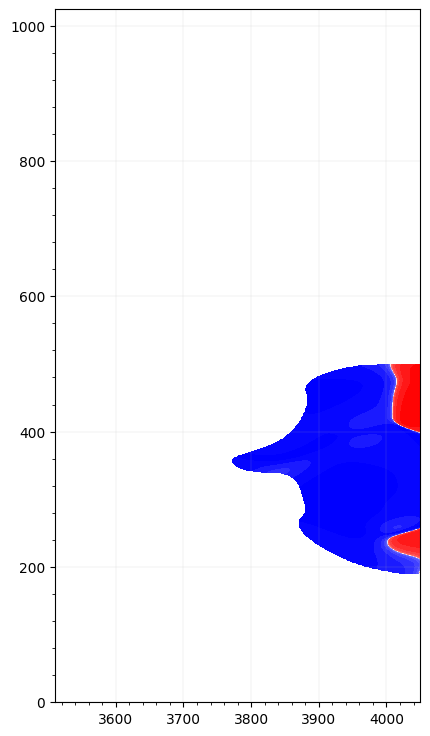

In [30]:
from matplotlib.ticker import AutoMinorLocator
fig,ax = plt.subplots(figsize=(12,9))
pv1= dfl1.pivot_table(index='y_grid', columns='x_grid', values='pn_log_k', aggfunc='median',)
levels=np.linspace(-5,5,33,)
vmin=-4
vmax=4
X=pv1.columns.values
Y=pv1.index.values
Z=pv1.values
cf=ax.contourf(
    X,
    Y,
    Z,
    levels=levels,
    cmap='bwr',
    vmin=vmin,
    vmax=vmax,
)
ax.grid(which='major', linewidth=0.3, alpha=0.4)
ax.set_aspect('equal')
ax.xaxis.set_minor_locator(AutoMinorLocator(5))
ax.yaxis.set_minor_locator(AutoMinorLocator(5))
ax.set_xlim(3510,4050)
ax.set_ylim(0,1024)  
